## Notebook 07 - MFCC Analysis

### Objective
Previous notebooks investigates low-level spectral descriptors such as RMS Energy, Spectrograms, and Spectral Centroid. These features describe <b>How much energy exists</b> and <b>where it is concentrated</b> in the spectrum. This notebook shifts the focus to <b>Mel-Frequency Cepstral Coefficients (MFCCs)</b>, which describe the overall <b>Spectral envelope</b> of an audio signal.

The primary research question is:
- <b> Do overlapping (subtle) anomalies exhibit a different spectral shape than normalrecordings?</b>

Unlike spectral centroid, MFCCs capture mutliple aspects of the spectral envelope rather than a single frequency statistic.

### Theory
<b> What are MFCCs ?</b>

Mel-Frequency Cepstral Coefficients (MFCCs) are one of the most widely used features in speech recognition and machine condition monitoring. unlike spectral centroid, which summarizes the spectrum using a single values, MFCCs describe the <b>shape of the spectral envelope</b>.

The extraction process consists of:
1. Short-Time Fourier Transform (STFT)
2. Mel Filter Bank
3. Log Mel Energy
4. Discrete Cosine Transform (DCT)

The resulting coefficients summarize different characteristics of the spectrum.

- MFCC-0 represents overall spectral energy.
- Lower-order coefficients capture the coarse spectral envelope.
- Higher-order coefficients capture finer spectral details.

If subtle anomalies preserve overall energy but modify the spectral envelope, MFCCs should reveal these changes more effectively than RMS or Spectral Centroid.

### Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from pathlib import Path

from src.config import *
from src.io import *
from src.utils import *
from src.feature import *
from src.visualization import *

In [3]:
group_a = pd.read_csv(results_path/"group_a.csv")
group_b = pd.read_csv(results_path/"group_b.csv")
group_c = pd.read_csv(results_path/"group_c.csv")
rms_summary = pd.read_csv(results_path/"rms_summary.csv")

### Computing MFCC Features for every recording

In [4]:
records = []
for _, row in rms_summary.iterrows():
    file_path = get_audio_path(row['file_name'], row['label'])
    signal, sr = load_channel(file_path)
    stats = mfcc_statistics(signal, sr)
    stats['file_name'] = row['file_name']
    stats['label'] = row['label']
    records.append(stats)
mfcc_summary = pd.DataFrame(records)

In [5]:
mfcc_summary.head()

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_17_mean,mfcc_17_std,mfcc_18_mean,mfcc_18_std,mfcc_19_mean,mfcc_19_std,mfcc_20_mean,mfcc_20_std,file_name,label
0,-285.324097,13.046962,61.081543,8.571634,-7.742035,7.418871,16.976044,6.905290,8.054357,6.616282,...,-0.096999,3.979113,-3.670382,3.697155,-4.089489,3.840694,-2.095833,3.601322,00000000.wav,Normal
1,-282.278412,10.958236,51.239525,7.887704,-11.985823,7.473280,5.065098,6.930391,1.280624,7.068424,...,-1.623434,4.129343,-2.175425,3.928446,-7.778471,4.005436,-7.840248,3.642836,00000001.wav,Normal
2,-284.630371,13.951112,60.277317,10.349363,-5.456760,8.053712,16.463049,7.541470,5.267432,6.943223,...,-1.709660,4.066159,-0.542535,4.208001,-1.267911,3.588923,-0.160735,3.821595,00000002.wav,Normal
3,-284.538452,11.082034,51.455029,7.180773,-4.688273,7.678319,9.098770,6.373854,1.492822,5.265297,...,1.572953,4.329129,-0.524022,3.945969,-6.199827,4.392107,-6.244669,3.975851,00000003.wav,Normal
4,-281.469513,10.882649,63.417408,7.536225,-6.258961,7.911538,18.218475,7.109123,2.336891,5.741307,...,-1.234870,3.771016,-2.442800,3.671000,-3.763920,3.474387,-1.010000,3.534326,00000004.wav,Normal


In [6]:
mfcc_summary.to_csv(results_path/"mfcc_summary.csv", index = False)

### Representative Groups

In [7]:
group_a_mfcc = mfcc_summary[
    mfcc_summary.file_name.isin(group_a.file_name) &
    mfcc_summary.label.isin(group_a.label)]
group_b_mfcc = mfcc_summary[
    mfcc_summary.file_name.isin(group_b.file_name) &
    mfcc_summary.label.isin(group_b.label)]
group_c_mfcc = mfcc_summary[
    mfcc_summary.file_name.isin(group_c.file_name) &
    mfcc_summary.label.isin(group_c.label)]


### MFCC Heatmaps

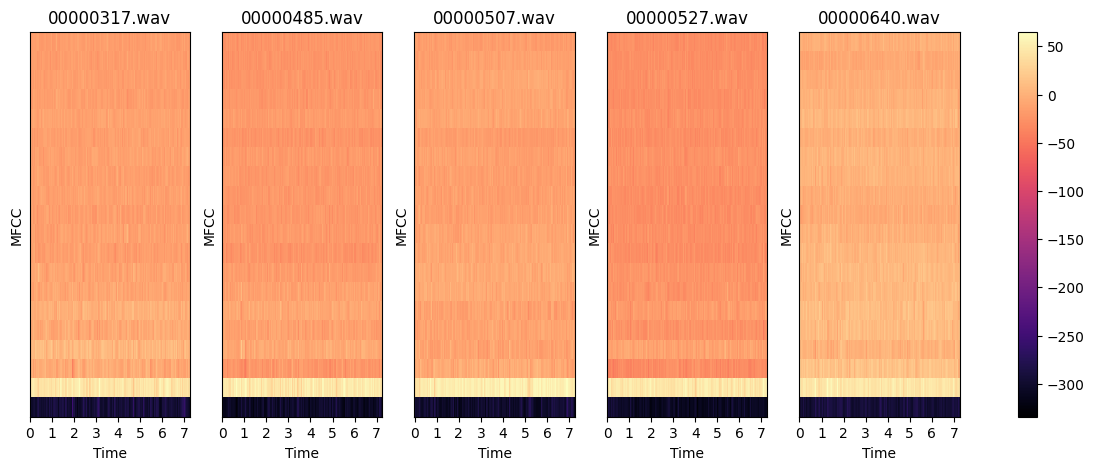

In [33]:
# Group A - Normal Files
fig, axes = plt.subplots(1, 5, figsize = (15, 5))
for ax, (_, row) in zip(axes, group_a_mfcc.iterrows()):
    signal, sr = load_channel(get_audio_path(row.file_name, row.label))
    img = plot_mfcc(signal, sr, ax = ax, title = row.file_name)
plt.colorbar(img, ax = axes)


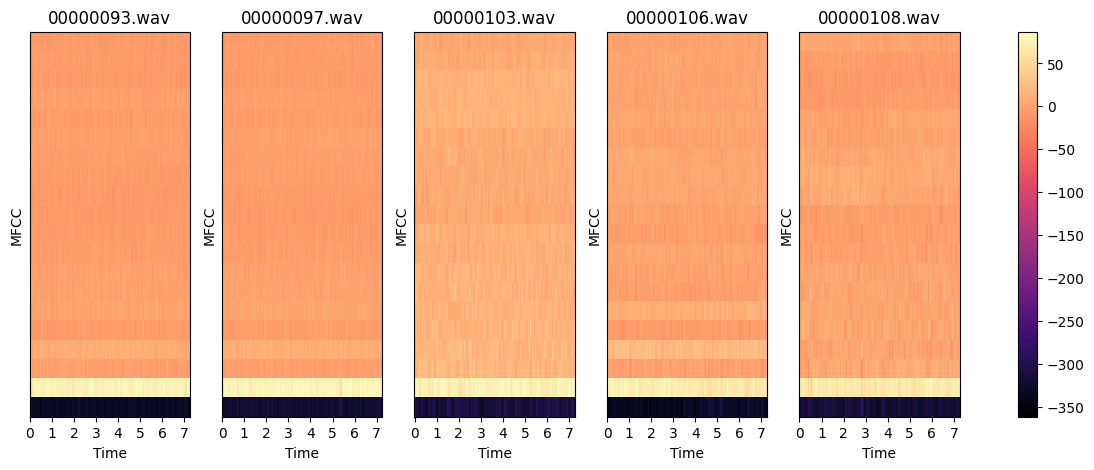

In [34]:
# Group B - Overlap Files
fig, axes = plt.subplots(1, 5, figsize = (15, 5))
for ax, (_, row) in zip(axes, group_b_mfcc.iterrows()):
    signal, sr = load_channel(get_audio_path(row.file_name, row.label))
    img = plot_mfcc(signal, sr, ax = ax, title = row.file_name)
plt.colorbar(img, ax = axes)

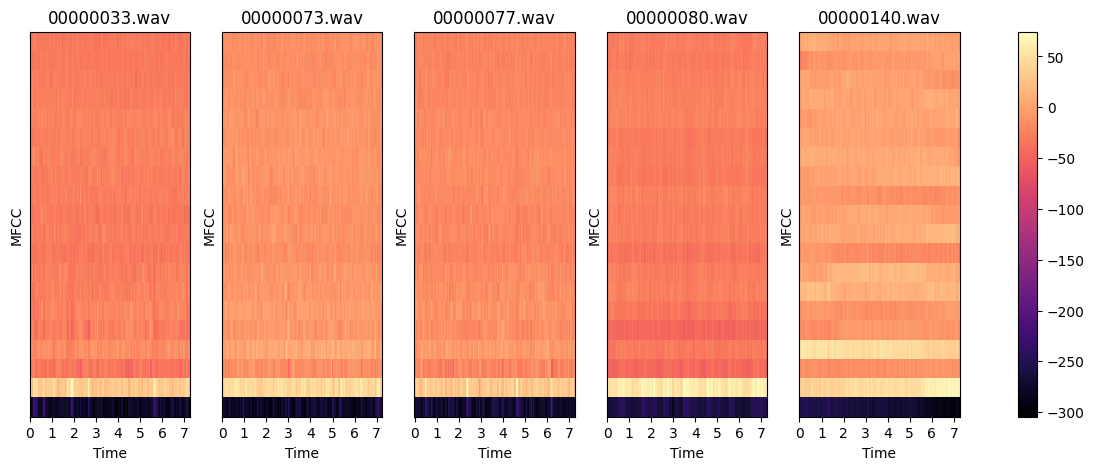

In [35]:
# Group C - Abnormal Files
fig, axes = plt.subplots(1, 5, figsize = (15, 5))
for ax, (_, row) in zip(axes, group_c_mfcc.iterrows()):
    signal, sr = load_channel(get_audio_path(row.file_name, row.label))
    img = plot_mfcc(signal, sr, ax = ax, title = row.file_name)
plt.colorbar(img, ax = axes)

### Mean MFCC Profile

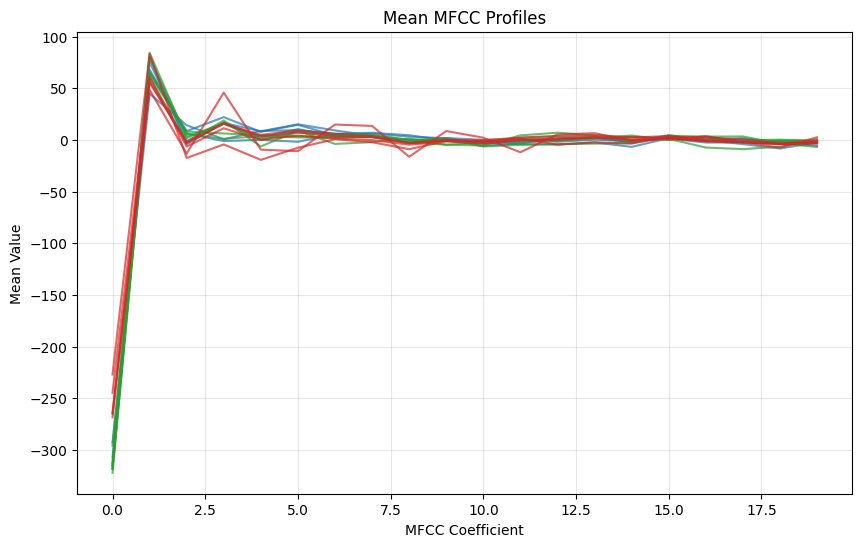

In [9]:
plt.figure(figsize = (10, 6))
for _, row in group_a_mfcc.iterrows():
    signal, sr = load_channel(get_audio_path(row.file_name, row.label))
    plt.plot(mean_mfcc_profile(signal, sr), alpha = 0.7, color = "tab:blue")

for _, row in group_b_mfcc.iterrows():
    signal, sr = load_channel(get_audio_path(row.file_name, row.label))
    plt.plot(mean_mfcc_profile(signal, sr), alpha = 0.7, color = "tab:green")

for _, row in group_c_mfcc.iterrows():
    signal, sr = load_channel(get_audio_path(row.file_name, row.label))
    plt.plot(mean_mfcc_profile(signal, sr), alpha = 0.7, color = "tab:red")

plt.xlabel("MFCC Coefficient")
plt.ylabel("Mean Value")
plt.title("Mean MFCC Profiles")
plt.grid(alpha = 0.3)
plt.show()

In [11]:
df = pd.read_csv(results_path/"mfcc_summary.csv")

In [12]:
# Isolating label 'Normal'
normal_mfcc_data = df.loc[df['label'] == 'Normal']
# Isolating label 'Abnormal'
abnormal_mfcc_data = df.loc[df['label'] == 'Abnormal']

In [13]:
normal_mfcc_data.describe()

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_16_mean,mfcc_16_std,mfcc_17_mean,mfcc_17_std,mfcc_18_mean,mfcc_18_std,mfcc_19_mean,mfcc_19_std,mfcc_20_mean,mfcc_20_std
count,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,...,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000,1006.000000
mean,-303.285556,11.463263,66.591560,7.994701,-1.554044,7.195472,12.667039,6.387819,2.235614,5.926783,...,0.629516,3.873135,-2.100891,3.820479,-2.066004,3.726854,-3.274120,3.649255,-2.183533,3.600728
std,14.739590,3.792424,12.062899,1.861053,6.433701,1.356826,6.641096,0.902439,3.850281,0.796102,...,2.887308,0.370090,2.806712,0.362285,2.517014,0.375280,2.410422,0.344824,2.215093,0.347371
min,-343.471830,5.319921,18.219568,3.903551,-31.722338,4.052751,-3.941948,4.220100,-12.286336,3.738831,...,-9.813645,3.014499,-12.178508,2.860035,-10.991632,2.887237,-12.458494,2.848328,-10.373295,2.854822
25%,-313.252705,9.392105,59.340753,6.845080,-4.591323,6.244144,6.986153,5.776273,0.148435,5.387019,...,-0.618188,3.610027,-2.976180,3.578183,-3.082932,3.475705,-4.441140,3.427009,-3.044379,3.376762
50%,-305.497360,10.832411,67.634500,7.881803,-1.661300,7.041207,15.464017,6.259259,2.148429,5.859066,...,1.045215,3.845478,-1.549760,3.791216,-1.765081,3.680978,-3.044500,3.613673,-1.873047,3.557400
75%,-290.630090,12.380494,75.058381,8.822327,2.035832,7.951352,17.538490,6.995707,4.729606,6.417551,...,2.322977,4.088311,-0.472263,4.028989,-0.507879,3.924876,-1.787118,3.836648,-0.889722,3.763428
max,-265.407780,49.057660,88.967490,29.826263,16.899748,17.037167,25.630093,9.718197,11.581146,8.807064,...,9.766317,6.855846,6.558552,6.107737,6.351057,6.430886,5.763379,7.114625,4.480264,6.149615


In [14]:
abnormal_mfcc_data.describe()

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_16_mean,mfcc_16_std,mfcc_17_mean,mfcc_17_std,mfcc_18_mean,mfcc_18_std,mfcc_19_mean,mfcc_19_std,mfcc_20_mean,mfcc_20_std
count,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,...,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000,143.000000
mean,-269.674077,14.749061,72.674755,10.039339,-5.004285,6.383915,10.293794,5.960432,-4.732109,6.115204,...,2.491082,3.564237,-0.021978,3.456776,-1.100059,3.450090,-2.966969,3.393000,-2.231615,3.345898
std,42.074594,7.060542,15.034894,4.368370,7.847858,1.960360,9.103766,1.819460,8.234306,2.097557,...,2.446730,0.492947,2.704201,0.566114,2.353427,0.534967,2.642181,0.482904,2.952001,0.420302
min,-352.565400,3.426366,24.643330,2.501140,-34.125400,2.649197,-9.191417,2.549064,-23.128569,2.549384,...,-4.958610,2.528901,-10.809322,2.590401,-10.902517,2.547962,-12.272613,2.492346,-8.996675,2.444556
25%,-318.127745,9.150725,62.127359,6.878272,-9.350088,5.180399,3.791553,4.457218,-11.121398,4.217939,...,0.987137,3.226176,-1.321376,3.056512,-2.235180,3.131677,-4.341572,3.112458,-3.920405,3.061579
50%,-247.873050,14.881266,72.338290,10.317934,-5.858937,6.644836,11.308414,6.412362,-3.876828,6.403285,...,3.118056,3.588877,0.017592,3.418253,-0.833446,3.403358,-2.662639,3.408422,-1.958503,3.382060
75%,-237.810310,20.658911,83.413385,13.168347,-0.995620,7.452599,14.614458,7.170382,1.620228,7.736527,...,4.409976,3.927665,1.437903,3.795604,0.605796,3.674795,-1.392629,3.655132,-0.514196,3.588362
max,-219.258940,42.621060,110.050970,28.611183,16.590462,14.893811,48.731857,14.717317,11.187275,11.077569,...,7.950020,5.103379,8.939361,7.031220,4.026085,5.802015,6.839589,5.675718,6.711116,4.970510


In [16]:
overlap_df = pd.read_csv(results_path/"rms_overlap_files.csv")

In [17]:
overlap_mfcc_data = mfcc_summary[
    mfcc_summary.file_name.isin(overlap_df.file_name) &
    mfcc_summary.label.isin(overlap_df.label)]

In [32]:
overlap_mfcc_data.to_csv(results_path/"overlap_mfcc_data.csv", index = False)

In [20]:
overlap_mfcc_data.describe()

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_16_mean,mfcc_16_std,mfcc_17_mean,mfcc_17_std,mfcc_18_mean,mfcc_18_std,mfcc_19_mean,mfcc_19_std,mfcc_20_mean,mfcc_20_std
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,...,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000
mean,-326.161896,8.867876,79.035263,6.359962,1.107186,5.158975,11.721388,4.479583,1.260430,3.958049,...,0.855909,3.263694,-0.698230,3.160651,-1.176079,3.136140,-2.097408,3.029611,-1.043350,3.040159
std,13.008582,7.117011,16.418125,4.596077,9.734486,2.544236,9.415109,1.488298,5.825750,1.034744,...,2.560348,0.568351,3.646710,0.437829,3.273267,0.429033,3.121859,0.368416,2.886810,0.414485
min,-352.565399,3.426366,24.643330,2.501140,-34.125401,2.649197,-9.191417,2.549064,-19.230602,2.549384,...,-4.958610,2.528901,-10.809322,2.590401,-10.902517,2.547962,-12.272613,2.492346,-8.847651,2.444556
25%,-333.638062,4.977977,70.842121,3.879451,-1.588737,3.163912,1.455760,3.079223,-2.967836,2.940347,...,-0.813473,2.878086,-1.958227,2.762925,-2.393816,2.795954,-3.401331,2.767794,-1.660391,2.738142
50%,-323.591980,7.505764,79.209030,5.485153,1.847233,4.654241,15.812954,4.464049,2.817945,3.957465,...,1.131508,3.151314,-0.496137,3.034033,-0.373778,3.049717,-1.786993,2.915994,-0.988118,2.931247
75%,-318.127747,9.167896,86.819534,7.206242,7.292534,6.153529,18.839180,5.896698,5.280941,4.851813,...,3.041529,3.550392,1.271571,3.566845,0.976648,3.391195,-0.614383,3.335763,0.156648,3.307074
max,-295.887177,42.621059,110.050972,28.611183,16.590462,14.893811,23.347504,7.864446,11.187275,5.758350,...,5.363681,5.103379,8.939361,4.132335,4.026085,4.469855,6.839589,3.853433,6.711116,4.039799


In [28]:
obvious_mfcc_data = mfcc_summary[
    (~mfcc_summary['file_name'].isin(overlap_df.file_name)) &
    (mfcc_summary['label'] == 'Abnormal')]

In [33]:
obvious_mfcc_data.to_csv(results_path/"obvious_mfcc_data.csv", index = False)

In [30]:
obvious_mfcc_data.head()

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_17_mean,mfcc_17_std,mfcc_18_mean,mfcc_18_std,mfcc_19_mean,mfcc_19_std,mfcc_20_mean,mfcc_20_std,file_name,label
1006,-242.650635,22.509523,78.217468,13.855007,-10.221791,7.003021,1.203103,5.693714,-16.275229,6.403285,...,0.840391,3.343387,2.568164,3.455487,-0.824440,3.414315,-3.580310,3.489871,00000000.wav,Abnormal
1007,-224.649658,17.485369,59.709946,20.506590,-7.508590,10.163268,-2.000360,6.416424,-19.556709,6.410371,...,0.524264,3.178959,-0.745319,3.221307,-2.600394,3.132927,-3.782912,2.779911,00000001.wav,Abnormal
1008,-239.012604,16.009939,83.446938,11.693311,-7.843162,6.818142,10.815055,5.693060,-10.995159,6.036542,...,2.137333,3.327755,-0.183101,3.273142,-2.178507,3.155447,-1.726789,3.539887,00000002.wav,Abnormal
1009,-240.727280,20.172394,82.879173,13.944656,-8.398624,6.272265,11.047417,6.425694,-11.994704,6.967851,...,3.977584,3.139121,2.925257,3.209427,1.436648,3.592740,1.593158,3.663430,00000003.wav,Abnormal
1010,-232.627640,17.488207,85.915184,11.995054,-8.872291,5.634790,9.630671,5.818780,-14.365468,5.822426,...,2.621953,3.179236,1.152767,3.381551,-0.873316,3.411009,-0.269792,3.020358,00000004.wav,Abnormal


In [31]:
obvious_mfcc_data.describe()

,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,mfcc_16_mean,mfcc_16_std,mfcc_17_mean,mfcc_17_std,mfcc_18_mean,mfcc_18_std,mfcc_19_mean,mfcc_19_std,mfcc_20_mean,mfcc_20_std
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,...,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000
mean,-242.018600,17.628389,69.560753,11.840701,-7.996359,6.983626,9.594870,6.685431,-7.665957,7.171310,...,3.291636,3.711378,0.309104,3.601753,-1.062840,3.603794,-3.392693,3.570909,-2.813370,3.495582
std,14.581818,4.949589,13.324670,2.884164,4.318573,1.226437,8.913878,1.503203,7.645306,1.621342,...,1.950276,0.374485,2.038203,0.567096,1.756858,0.515764,2.271251,0.430730,2.819538,0.334630
min,-329.879242,5.358700,30.087111,3.488470,-18.053030,3.897155,-6.572786,3.671593,-23.128569,3.374617,...,-1.869744,2.933702,-4.759913,2.726565,-6.788953,2.743367,-9.301458,2.834966,-8.996675,2.779911
25%,-247.878078,14.289789,60.535426,10.230854,-10.762260,6.272333,4.435207,6.301795,-12.813177,6.383735,...,1.979652,3.444846,-1.183192,3.173973,-2.160423,3.293038,-4.508860,3.292740,-4.171376,3.324962
50%,-240.729553,17.145710,67.613621,12.375862,-6.970745,7.049712,10.681364,6.870558,-6.660134,7.539515,...,3.751959,3.663589,0.180305,3.587645,-1.170604,3.504706,-3.284435,3.516568,-2.896022,3.501039
75%,-234.966484,21.657596,82.692526,13.645142,-5.073991,7.834060,12.398264,7.364549,-0.987992,8.179900,...,4.533145,3.979379,1.505087,3.864117,0.323896,3.728124,-1.689406,3.749964,-1.658463,3.665982
max,-219.258942,27.694550,93.869919,20.506590,5.407479,10.163268,48.731857,14.717317,6.602371,11.077569,...,7.950020,5.007233,4.618521,7.031220,2.925257,5.802015,1.436648,5.675718,3.489562,4.970510


### Observation

1. After splitting the abnormal class into overlap and obvious subsets, MFCC statistics reveal a clear ordering:<b> overlap anomalies are quieter and more stable than normal (lower mfcc_1 mean, lower std), while obvious anomalies are louder and much more variable (higher mfcc_1 mean, higher std) — with normal recordings sitting in between.</b> This shift is concentrated almost entirely in the first 1–2 coefficients (overall spectral energy/shape), while higher-order coefficients (fine spectral detail) stay stable across all three groups. This confirms MFCCs can separate all three classes, but the discriminating signal lives in low-order coefficient statistics, not visual texture or high-order detail.
2. <b> Non-monotonic behaviour in mid-range coefficients(mfcc_3, mfcc_4, mfcc_5): </b> Unlike mfcc_1 (which shifts cleanly in one direction: Overlap -> Normal -> Obvious), coefficients like mfcc_3 and mfcc_5 don't follow that same clean order:
   * mfcc_3_mean: Normal(-1.55) -> Overlap(+1.11) -> Obvious (-8.00)
   * mfcc_5_mean: Normal(2.24) -> Overlap(1.26) -> Obvious(-7.67)


    Here, Overlap is actually closer to zero or even above Normal, while Obvious     swings sharply negative. This is a different, non-linear pattern compared to mfcc_1's monotonic trend. It suggests overlap and obvious anomalies might not just be "two points on the same severity scale" — they could reflect different underlying fault mechanisms, not simply "mild version vs strong version" of the same anomaly. 

## Question : Which MFCC coefficients actually separate the three groups?

In [58]:
results_path.mkdir(exist_ok = True)
(results_path/"figures").mkdir(exist_ok = True)
(results_path/"figures"/"mfcc").mkdir(exist_ok = True)

### Coefficient-wise Mean Comparison

In [34]:
def coefficient_columns(prefix):
    return[f"{prefix}_{i}_mean" for i in range(1, 21)]

In [35]:
mfcc_mean_cols = coefficient_columns("mfcc")

In [36]:
normal_mean = group_a_mfcc[mfcc_mean_cols].mean()
overlap_mean = group_b_mfcc[mfcc_mean_cols].mean()
obvious_mean = group_c_mfcc[mfcc_mean_cols].mean()

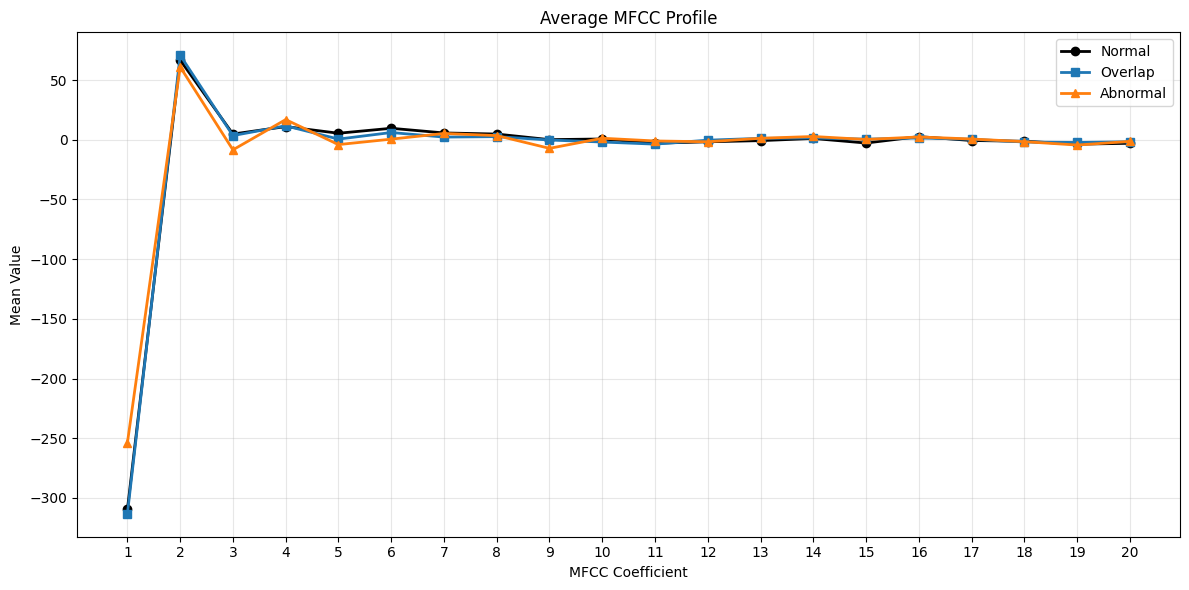

In [60]:
plt.figure(figsize = (12, 6))
plt.plot(range(1, 21), normal_mean, marker = 'o', linewidth = 2, label = "Normal", color = 'black')
plt.plot(range(1, 21), overlap_mean, marker = 's', linewidth = 2, label = "Overlap")
plt.plot(range(1, 21), obvious_mean, marker = '^', linewidth = 2, label = "Abnormal")
plt.xlabel("MFCC Coefficient")
plt.ylabel("Mean Value")
plt.title("Average MFCC Profile")
plt.xticks(range(1, 21))
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.savefig(results_path/"figures"/"mfcc"/"mfcc_mean_profile.png",
            dpi = 150, bbox_inches = "tight")
plt.show()

### Coefficient-wise Standard Deviation

In [40]:
std_cols = [f"mfcc_{i}_std" for i in range(1, 21)]
normal_std = group_a_mfcc[std_cols].mean()
overlap_std = group_b_mfcc[std_cols].mean()
obvious_std = group_c_mfcc[std_cols].mean()

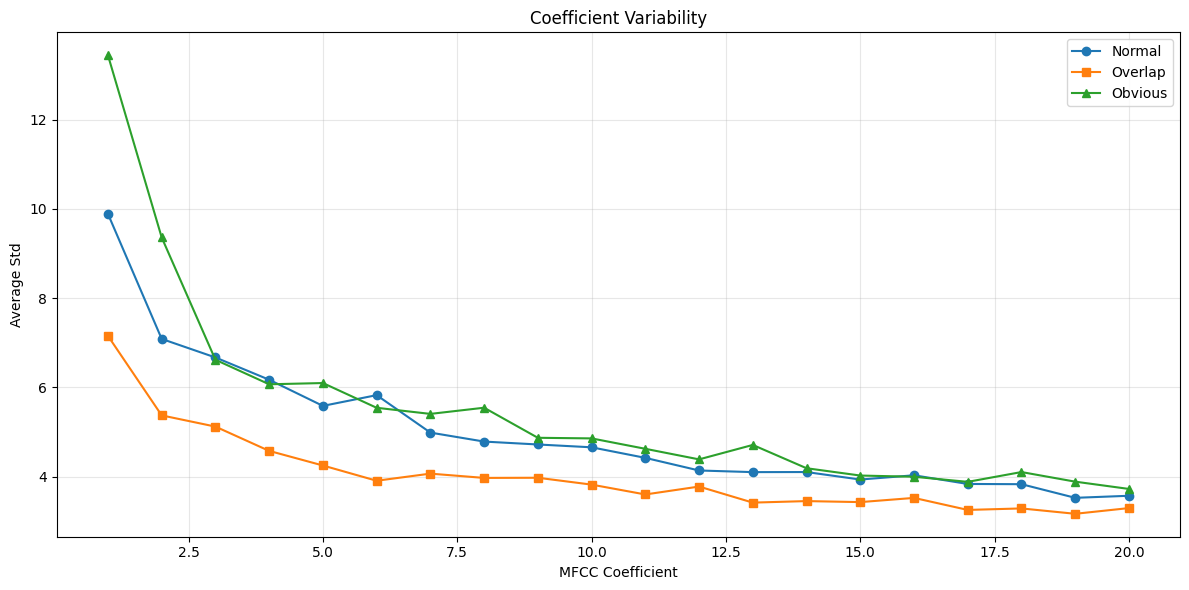

In [61]:
plt.figure(figsize=(12,6))
plt.plot(range(1,21), normal_std, marker="o", label="Normal")
plt.plot(range(1,21), overlap_std, marker="s", label="Overlap")
plt.plot(range(1,21), obvious_std, marker="^", label="Obvious")
plt.xlabel("MFCC Coefficient")
plt.ylabel("Average Std")
plt.title("Coefficient Variability")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(results_path/"figures"/"mfcc"/"mfcc_std_profile.png", dpi = 150,
            bbox_inches = "tight")
plt.show()

### Boxplot - first 5 MFCC features (as they carry most of the energy and envelope information)

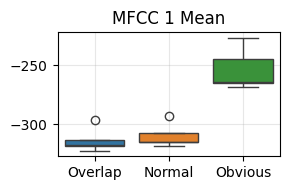

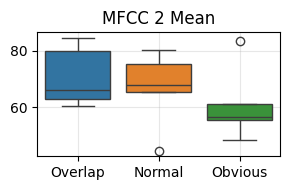

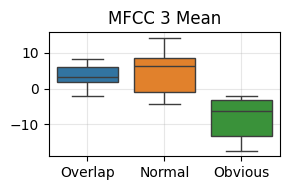

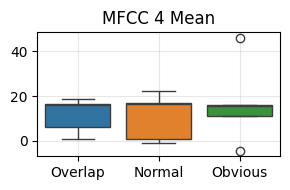

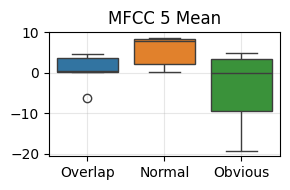

In [63]:
import seaborn as sns

for coeff in range(1,6):
    plt.figure(figsize=(3,2))
    sns.boxplot(
        data=[
            group_b_mfcc[f"mfcc_{coeff}_mean"].values,
            group_a_mfcc[f"mfcc_{coeff}_mean"].values,
            group_c_mfcc[f"mfcc_{coeff}_mean"].values
        ]
    )
    plt.xticks(
        [0,1,2],
        ["Overlap","Normal","Obvious"]
    )
    plt.title(f"MFCC {coeff} Mean")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(results_path/"figures"/"mfcc"/f"mfcc{coeff}_mean_boxplot.png",
                dpi = 150, bbox_inches = "tight")

    plt.show()

### Variability Boxplots

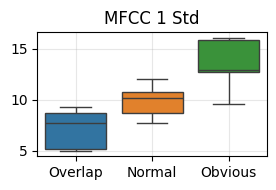

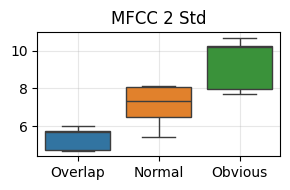

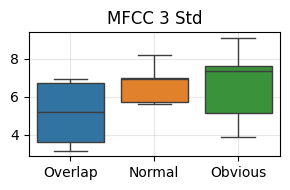

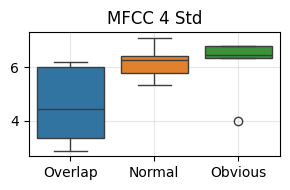

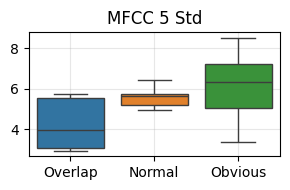

In [64]:
for coeff in range(1,6):
    plt.figure(figsize=(3,2))
    sns.boxplot(
        data=[
            group_b_mfcc[f"mfcc_{coeff}_std"].values,
            group_a_mfcc[f"mfcc_{coeff}_std"].values,
            group_c_mfcc[f"mfcc_{coeff}_std"].values ])
    plt.xticks(
        [0,1,2],
        ["Overlap","Normal","Obvious"]
    )
    plt.title(f"MFCC {coeff} Std")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(results_path/"figures"/"mfcc"/f"mfcc{coeff}_std_boxplot.png",
                dpi = 150, bbox_inches = "tight")
    plt.show()

### Violin Plots

Vilion plots reveal distribution shape and skewness.

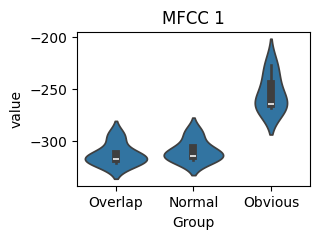

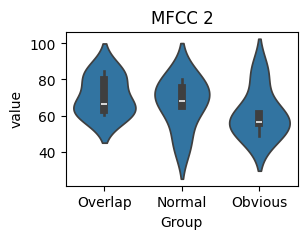

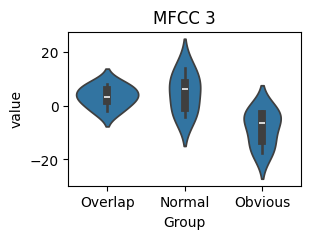

In [47]:
for coeff in [1,2,3]:
    df = pd.DataFrame({
        "value": pd.concat([
            group_b_mfcc[f"mfcc_{coeff}_mean"],
            group_a_mfcc[f"mfcc_{coeff}_mean"],
            group_c_mfcc[f"mfcc_{coeff}_mean"]
        ]),
        "Group": (
            ["Overlap"]*len(group_b_mfcc) + ["Normal"]*len(group_a_mfcc) +
            ["Obvious"]*len(group_c_mfcc))
    })
    plt.figure(figsize=(3,2))
    sns.violinplot(
        data=df,
        x="Group",
        y="value"
    )
    plt.title(f"MFCC {coeff}")
    plt.show()

### Correlation Matrix

Redundancy among MFCC coefficients

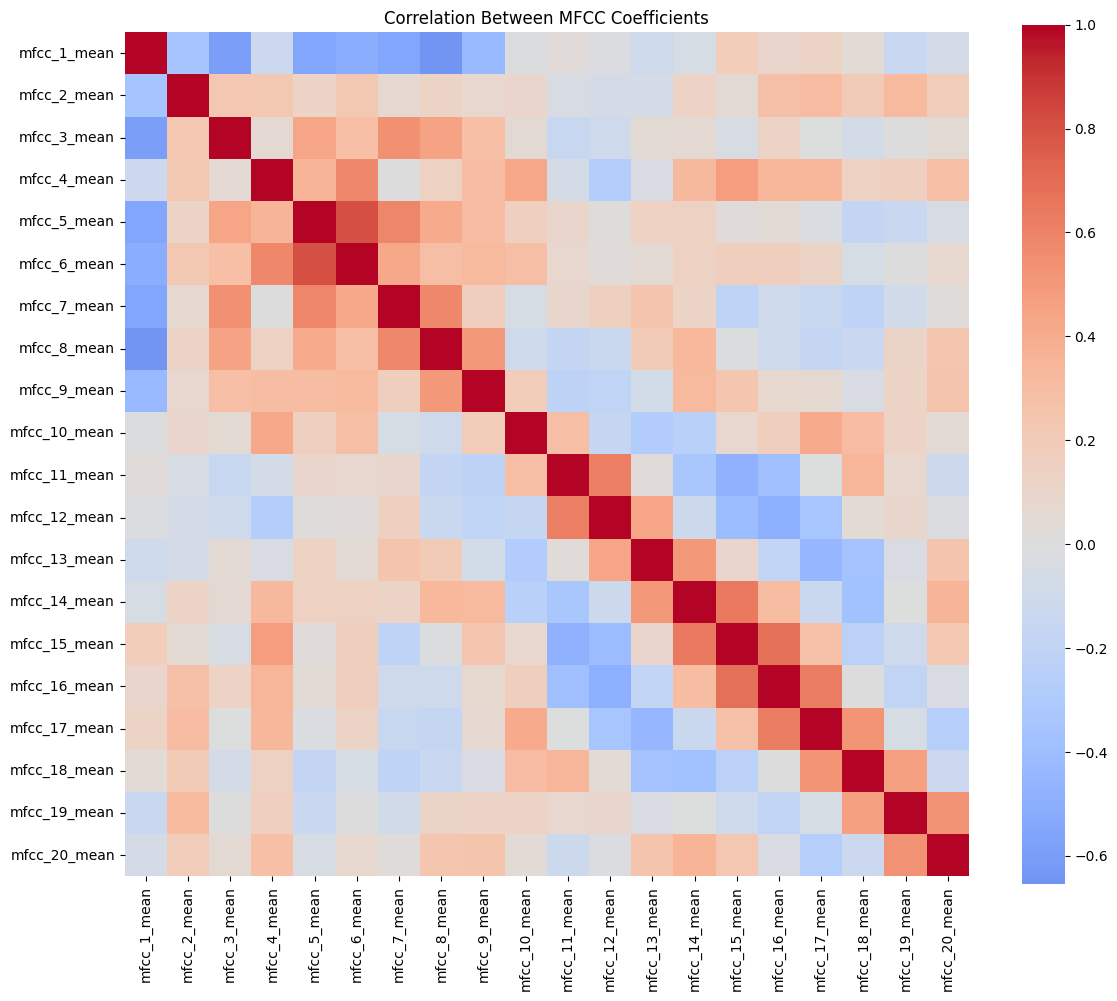

In [66]:
corr = mfcc_summary[mfcc_mean_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Correlation Between MFCC Coefficients")
plt.tight_layout()
plt.savefig(results_path/"figures"/"mfcc"/f"mfcc_correlation_matrix.png",
                dpi = 150, bbox_inches = "tight")
plt.show()

### Summary Table

In [52]:
summary = pd.DataFrame({
    "Normal": normal_mean,
    "Overlap": overlap_mean,
    "Obvious": obvious_mean
})
summary.head()

,Normal,Overlap,Obvious
mfcc_1_mean,-309.696442,-313.333435,-253.895721
mfcc_2_mean,66.772163,70.778503,61.043694
mfcc_3_mean,4.768622,3.494830,-8.459711
mfcc_4_mean,11.028834,11.674437,16.877604
mfcc_5_mean,5.454135,0.551692,-4.047482


In [53]:
summary.to_csv(results_path/"mfcc_group_summary.csv")

### Identify Most Discriminative Coefficients

In [55]:
difference = pd.DataFrame({
    "Coefficient": range(1, 21),
    "Overlap-Normal": overlap_mean.values - normal_mean.values,
    "Obvious-Normal": obvious_mean.values - normal_mean.values
})
difference

,Coefficient,Overlap-Normal,Obvious-Normal
0,1,-3.636993,55.800720
1,2,4.006340,-5.728470
2,3,-1.273793,-13.228333
3,4,0.645602,5.848769
4,5,-4.902443,-9.501616
5,6,-3.548129,-9.090827
6,7,-3.467844,-0.441428
7,8,-2.154778,-1.280149
8,9,-0.310702,-7.277269
9,10,-2.554793,0.615261


In [57]:
difference["Importance"] = (
    difference["Overlap-Normal"].abs() + difference["Obvious-Normal"].abs())

difference.sort_values("Importance", ascending=False)

,Coefficient,Overlap-Normal,Obvious-Normal,Importance
0,1,-3.636993,55.800720,59.437714
2,3,-1.273793,-13.228333,14.502127
4,5,-4.902443,-9.501616,14.404059
5,6,-3.548129,-9.090827,12.638956
1,2,4.006340,-5.728470,9.734810
8,9,-0.310702,-7.277269,7.587971
3,4,0.645602,5.848769,6.494371
14,15,3.230833,2.976229,6.207062
6,7,-3.467844,-0.441428,3.909271
12,13,1.908713,1.976942,3.885655


### Overall Summary

The analysis across all five visualization types points to the same consistent conclusion:

<b>The first two coefficients (mfcc_1 and mfcc_2) are by far the strongest separators</b>, both in terms of mean shift and internal variability. Their opposing directions of change between Overlap and Obvious make them complementary rather than redundant. mfcc_3 and mfcc_5 add some additional power specifically for separating Obvious from the rest, but cannot distinguish Overlap from Normal. Everything from mfcc_6 onwards contributes negligible separation.

For any classifier we build next, a compact feature vector of <b>{mfcc_1_mean, mfcc_1_std, mfcc_2_mean, mfcc_2_std, mfcc_3_mean}</b> would likely capture nearly all the discriminative information available from MFCCs, without the noise and redundancy of using all 20 features.